# Experiments for Randers-Finsler HMC

In [1]:
import torch
from torch import Tensor
from geodesic_toolbox import ExplicitRHMCSampler
from geodesic_toolbox.solvers import GEORCEFinsler
from geodesic_toolbox.cometric import DualRandersMetrics, CoMetric
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gaussian_kde
import warnings

## 1 - Preliminaries

### 1.1. Definition of a Randers metric

We equipe the Euclidian space $(\mathbb R^2, \bar g)$ with the following one form : 
\begin{equation*}
    \omega = \frac{\eta}{\|d\theta\|}d\theta = \eta(\frac{-y}{\sqrt{x^2 + y^2}}dx + \frac{x}{\sqrt{x^2 +y^2}}dy)
\end{equation*}
where $0 \le \eta <1$ ensures that this defines a Randers metric. 

In [2]:
from geodesic_toolbox import IdentityCoMetric
from geodesic_toolbox.cometric import RandersMetrics


class OneForm_dtheta(torch.nn.Module):
    """ Implements the normalized 1-form d theta in cartesian coordinate system.
    """

    def __init__(self, eta : float):
        super().__init__()
        self.eta = eta
    
    def forward(self, z : Tensor) -> Tensor :
        """Returns the vector representation of the 1-form d theta at a given point. 
        The 1-form is then computed with a dot product : 
        omega_z(v) = <omega(z), p>_g

        Args:
            z (Tensor): (Batch of) points on the manifold of shape (N_batch, 2)

        Returns:
            Tensor: (Batch of) tangent vectors that represent the 1-form of shape (N_batch, 2)
        """
        norm2 = torch.sum(z**2, axis = 1)
        norm = torch.sqrt(norm2)
        covect = torch.zeros_like(z)
        covect[:, 0] = -z[:,1]/norm
        covect[:, 1] = z[:,0]/norm
        return self.eta * covect


eta = 0.6
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

In [3]:
from torch.special import erf

def rect_fun(x : torch.Tensor, sigma : torch.Tensor = torch.tensor([0.1]) ) -> torch.Tensor : 
    """ Convolution between a rectangle function and a gaussian of standard deviation sigma

    Args:
        x (torch.Tensor): (Batch of) arguments for the function of shape (N_batch, 1)
        sigma (torch.Tensor) : Standard deviation of the convolution of shape (1,)

    Returns:
        torch.Tensor: (Batch of) outputs of shape (N_batch, 1)
    """ 
    sqrt2 = torch.sqrt(torch.tensor([2]))
    result = 0.5*(erf((x+1)/(sqrt2*sigma)) - erf((x-1)/(sqrt2*sigma)))
    return result
 


class RingCometricRect(CoMetric):
    """Implements the Riemannian metric described above on the ring manifold

    Attibutes:
        alpha (torch.Tensor): Half the width of the ring of shape (1,).

        **Inherited Attributes:**
       See :class:`CoMetric` for base CoMetric parameters 
        
    """

    def __init__(self, alpha : torch.Tensor):
        super().__init__(is_diag = True)
        assert alpha<1
        self.alpha = alpha
        

    def forward(self, p : torch.Tensor) -> torch.Tensor : 
        """Returns the cometric tensor by inverting the metric tensor

        Args:
            p (torch.Tensor):  (Batch of) points on the manifold of shape (N_batch, 2).

        Returns:
            torch.Tensor: (Batch of) cometric tensors of shape (N_batch, 2, 2).
        """
        norm = torch.sqrt(torch.sum(p**2, dim = 1, keepdim = True))
        rect_val = rect_fun((1-norm)/self.alpha)
        diags = rect_val.expand(-1,2)
        return 1/diags

def bump_fun(x : torch.Tensor) -> torch.Tensor : 
    """ Smooth bump function whose support is ]-1, 1[ : 
    Psi(x) = exp(1/(x^2 -1)) if x in ]-1, 1[ and 0 otherwise

    Args:
        x (torch.Tensor): (Batch of) arguments for the function of shape (N_batch, 1)

    Returns:
        torch.Tensor: (Batch of) outputs of shape (N_batch, 1)
    """ 
    inside = (x > -1) & (x < 1)
    safe_exp = torch.exp(1 / (x**2 - 1))
    return torch.where(inside, safe_exp, torch.zeros_like(x))
 


class RingCometricBump(CoMetric):
    """Implements the Riemannian metric described above on the ring manifold

    Attibutes:
        alpha (torch.Tensor): Half the width of the ring of shape (1,).

        **Inherited Attributes:**
       See :class:`CoMetric` for base CoMetric parameters 
    """

    def __init__(self, alpha : torch.Tensor):
        super().__init__(is_diag = True)
        assert alpha<1
        self.alpha = alpha
        

    def forward(self, p : torch.Tensor) -> torch.Tensor : 
        """Returns the cometric tensor by inverting the metric tensor

        Args:
            p (torch.Tensor):  (Batch of) points on the manifold of shape (N_batch, 2).

        Returns:
            torch.Tensor: (Batch of) cometric tensors of shape (N_batch, 2).
        """
        norm = torch.sqrt(torch.sum(p**2, dim = 1, keepdim = True))
        bump_val = bump_fun((1-norm)/self.alpha)
        diags = bump_val.expand(-1,2)
        return 1/diags

Visualization of the covector field.

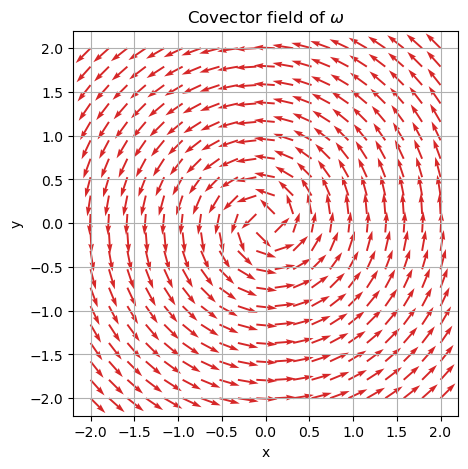

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
# Create a grid of points
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid the origin to prevent division by zero
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]
pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Covector field of $\omega$")
ax.grid(True)
plt.show()

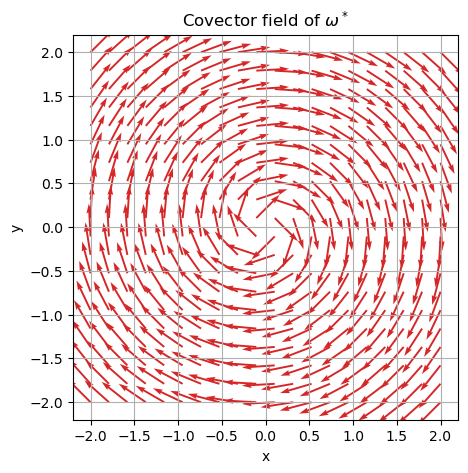

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
# Create a grid of points
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid the origin to prevent division by zero
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]
pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = randers_cometric.omega_star(pts_tensor).detach().numpy()

ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Covector field of $\omega^*$")
ax.grid(True)
plt.show()

### 1.2 Sampling from Finsler (skewed) Gaussian

We want to sample from the following probability density on the initial momentum : 
\begin{equation*}
    \pi(p|z)=\frac{\sigma_{BH}^*(z)}{(2\pi)^{d/2}}\exp\left(-\frac{1}{2}(\sqrt{p^TG^*(z)p} + p^T \omega^*)^2\right)
\end{equation*}


#### 1.2.1 Visualization of the probability density funciton

In [4]:
w = torch.tensor([0.1, 0.2])

M = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

Text(0.4000000014901161, 0.5000000029802323, '$\\omega^*$')

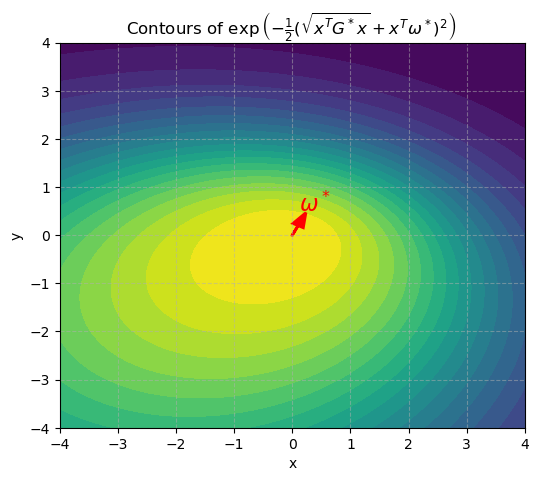

In [5]:
# If w and M are torch tensors, convert to numpy. 
# If they're already numpy arrays, leave them as is.
if hasattr(w, "numpy"):
    w = w.numpy()
if hasattr(M, "numpy"):
    M = M.numpy()

# Make a grid of (x, y) points
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
XY = np.stack([X, Y], axis=-1)  # shape (200, 200, 2)

# Compute sqrt(x^T M x) for each point in the grid
norm_M_XY = np.sqrt(np.einsum('...i,ij,...j->...', XY, M, XY))

# Compute x^T w for each point
dot_XY_w = XY @ w
Z = np.exp(-0.5 * (norm_M_XY + dot_XY_w) ** 2)

plt.figure(figsize=(6, 5))
contourf = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.xlabel("x")
plt.title(r"Contours of $\exp\left(-\frac{1}{2}(\sqrt{x^T G^* x} + x^T \omega^*)^2\right)$ ")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.5, linestyle="--")
# Add an arrow to indicate the direction of w and display the label using annotate
arrow_start = np.array([0.0, 0.0])  # arrow starts at the origin
plt.arrow(
    arrow_start[0],
    arrow_start[1],
    w[0],
    w[1],
    head_width=0.2,
    head_length=0.3,
    fc="red",
    ec="red",
    linewidth=2,
)
# Add a label with LaTeX at the arrow tip
arrow_tip = arrow_start + w
plt.annotate(
    r"$\omega^*$",
    xy=(arrow_tip[0], arrow_tip[1]),
    xytext=(arrow_tip[0]+0.3, arrow_tip[1]+0.3),
    color="red",
    fontsize=16,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", linewidth=0),  # invisible arrow for alignment
    ha='center'
)

#### 1.2.2 Symmetric Random Walk Sampler of the momentum distribution

In [9]:
w = torch.tensor([0.1, 0.2])

M = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

In [10]:
def ll(z : Tensor, M : Tensor, w : Tensor) -> Tensor : 
    """Computes the log likelihood for the initial momentum distribution

    Args:
        z (Tensor): (Batch of) entries of shape (b, d)
        M (Tensor): Metric matrix of shape (d,d)
        w (Tensor): Randers covector of shape (d,)

    Returns:
        Tensor: (Batch of) log likelihood of shape (b,d)
    """
    norm_z = torch.sqrt(torch.einsum("bi,bj,ij->b",z,z,M))
    omega_z = z @ w
    return -0.5 * (norm_z + omega_z)**2

def momentum_mcmc_sampler(z0 : Tensor, l : int, sigma : float, M : Tensor, w : Tensor, return_acceptance : bool = False )-> Tensor :
    """
    Performs l steps of a symmetric random walk Metropolis sampler for the momentum distribution
    Args:
        z0 (Tensor): Initial value/batch of values of shape (b, d).
        l (int): Number of Metropolis steps to perform.
        sigma (float): Proposal standard deviation (step size of the Gaussian random walk).
        M (Tensor): Metric matrix of shape (d, d), positive definite.
        w (Tensor): Randers covector of shape (d,).

    Returns:
        Tensor: Final sample(s) after l Metropolis steps, of shape (b, d).
    """
    z = z0.clone()
    n_accept = 0
    n_total = 0
    L = torch.linalg.cholesky(M)
    for _ in range(l): 
        prop = z + sigma * torch.randn_like(z) @ torch.linalg.inv(L).T
        log_alpha = ll(prop, M, w) - ll(z, M, w)   # (b,)
        u = torch.log(torch.rand(z.shape[0], device=z.device))  # (b,)
        mask = (u < log_alpha)  # (b,)

        n_accept += mask.sum().item()
        n_total += z.shape[0]

        mask_unsq = mask.unsqueeze(1)
        z = torch.where(mask_unsq, prop, z)

    if return_acceptance:
        acceptance_rate = n_accept / n_total if n_total > 0 else 0.0
        return z, acceptance_rate
    else:
        return z

In [11]:
z0 = torch.randn(10**6, 2)
l = 20
sigma = 1.7
z, acc = momentum_mcmc_sampler(z0, l, sigma, M, w, return_acceptance= True)
print(acc)

0.4288334


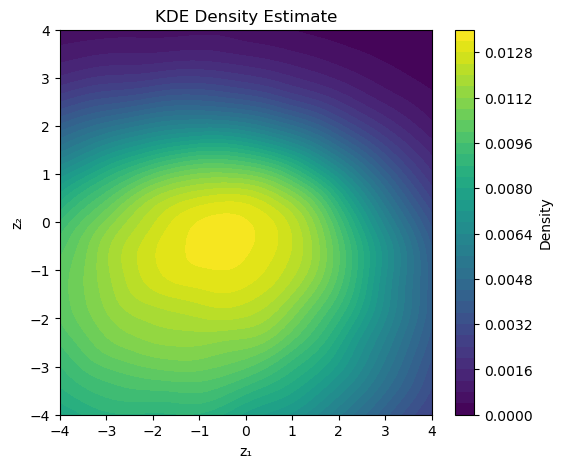

In [12]:
z_np = z.detach().cpu().numpy()
x, y = z_np[:, 0], z_np[:, 1]

# KDE
kde = gaussian_kde(z_np.T)

# Grid
grid_size = 150
xgrid = np.linspace(-4, 4, grid_size)
ygrid = np.linspace(-4, 4, grid_size)
xx, yy = np.meshgrid(xgrid, ygrid)

grid_points = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_points).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

cf = ax.contourf(xx, yy, zz, levels=40)
plt.colorbar(cf, ax=ax, label="Density")

ax.set_xlim([-4, 4])
ax.set_ylim([-4, 4])
ax.set_xlabel("z₁")
ax.set_ylabel("z₂")
ax.set_title("KDE Density Estimate")

plt.show()

#### 1.2.3 Exact sampling

##### Definition of the algorithm

Code for Legendre transform :

In [9]:
def reversed_legendre(p: torch.Tensor, G_star: torch.Tensor, w_star: torch.Tensor, eps: float = 1e-12,) -> torch.Tensor:
    """
    Reverse Legendre transform for a dual Randers norm.

    Args:
        p:      (batch, d) covectors
        G_star: (d, d) dual metric matrix
        w_star: (d,) dual drift vector
        eps:    small positive number to avoid division by zero

    Returns:
        (batch, d) vectors v = d_p (1/2 F^*(p)^2)
    """
    quad = torch.einsum("...i,...ij,...j->...", p, G_star, p)
    norm_term = torch.sqrt(quad.clamp_min(eps))
    dot_term = torch.einsum("...i,...i->...", p, w_star)

    F_star = norm_term + dot_term
    Gp = torch.einsum("...ij,...j->...i", G_star, p)

    return F_star.unsqueeze(-1) * (Gp / norm_term.unsqueeze(-1) + w_star)
    
def legendre_randers(v: torch.Tensor, G: torch.Tensor, w: torch.Tensor, eps: float = 1e-12,) -> torch.Tensor:
    """
    Legendre transform for a dual Randers norm.

    Args:
        v:      (batch, d) covectors
        G: (d, d) dual metric matrix
        w: (d,) dual drift vector
        eps:    small positive number to avoid division by zero

    Returns:
        (batch, d) vectors p = d_v (1/2 F(v)^2)
    """
    quad = torch.einsum("...i,...ij,...j->...", v, G, v)
    norm_term = torch.sqrt(quad.clamp_min(eps))
    dot_term = torch.einsum("...i,...i->...", v, w)

    F = norm_term + dot_term
    Gv = torch.einsum("...ij,...j->...i", G, v)

    return F.unsqueeze(-1) * (Gv / norm_term.unsqueeze(-1) + w)


z = torch.tensor([[0., 1.]])
G_star = randers_cometric.G_star(z)      # probably (1, d, d)
w_star = randers_cometric.omega_star(z)  # probably (1, d)

G = torch.eye(2).unsqueeze(0)            # make batched if needed
w = omega_form(z)                        # probably (1, d)


p = torch.randn(10000, 2)

v = reversed_legendre(p, G_star, w_star)
p_bis = legendre_randers(v, G, w)

errors = (p_bis - p).norm(dim=1)
print("Largest error over 1000 tests:", errors.max().item())

Largest error over 1000 tests: 5.5159262046799995e-06


Definition of the sampling algorithm.

In [14]:
def moebius_transform(u: Tensor, mu: Tensor, rho: Tensor, M: Tensor) -> Tensor:
    """
    Applies a Möbius transformation relevant to sampling on Riemannian manifolds.

    Args:
        u (Tensor): Input points of shape (batch_size, d).
        mu (Tensor): Mean direction vector of shape (d,).
        rho (Tensor): Scalar parameter controlling rotation/stretch (tensor scalar).
        M (Tensor): Symmetric positive definite matrix (covariance or metric) of shape (d, d).

    Returns:
        Tensor: Transformed points of shape (batch_size, d) after applying the Möbius transformation.
    """
    inner_prod = (u @ M @ mu).unsqueeze(-1) # (batch_size, 1)
    
    num = (1 - rho**2) * (u + rho * mu)
    den = 1 + 2 * rho * inner_prod + rho**2
    return (num / den) + rho * mu

def riemann_sphere_uniform_sampler(batch_size: int, d: int, L: Tensor) -> Tensor:
    """
    Uniformly samples points from the unit sphere with respect to the induced metric defined by L on ℝ^d.

    Args:
        batch_size (int): Number of points to sample.
        d (int): Dimension of the sphere (ambient space dimension).
        L (Tensor): Cholesky factor of a positive-definite matrix (d x d), typically representing the metric.

    Returns:
        Tensor: An array of shape (batch_size, d) containing batch_size points uniformly sampled on the
        L-induced unit sphere.
    """
    z = torch.randn(batch_size, d)
    z_unit = z / torch.linalg.norm(z, dim=-1, keepdim=True)
    
    # Solve L.T @ v = z_unit for the whole batch
    v = torch.linalg.solve_triangular(
        L.mT, 
        z_unit.mT, 
        upper=True
    ).mT
    
    return v


def momentum_exact_sampler(M: Tensor, w: Tensor, batch_size: int = 1, return_stats: bool = False):
    """
    Samples the initial momentum for the FHMC algorithm, exactly according to distribution induced by kinetic energy.

    Args:
        M (Tensor): The symmetric positive definite metric tensor of shape (d, d).
        w (Tensor): The potential vector of length d, defining the linear drift in momentum space.
        batch_size (int, optional): Number of independent momentum samples to generate. Defaults to 1.
        return_stats (bool, optional): If True, also returns the mean number of proposal iterations per sample. Defaults to False.

    Returns:
        Tensor: Sampled momentum tensor of shape (batch_size, d).
        float (optional): If return_stats is True, average number of iterations per sample is also returned.
    """
    d = M.shape[0]

    # Pre-computations
    M_inv = torch.linalg.inv(M)
    L = torch.linalg.cholesky(M)
    beta = torch.sqrt(w @ M_inv @ w)
    mu = -M_inv @ w / beta
    rho = beta / (1 + torch.sqrt(1 - beta**2))
    
    # Initialize containers for the accepted directions u'
    final_u_prime = torch.zeros((batch_size, d))
    accepted_mask = torch.zeros(batch_size, dtype=torch.bool)
    
    if return_stats: 
        iterations_per_sample = torch.zeros(batch_size)
    
    # Acceptance-Rejection for the direction u'
    while not accepted_mask.all():
        active_indices = torch.where(~accepted_mask)[0]
        num_to_sample = len(active_indices)
        
        if return_stats:   
            iterations_per_sample[active_indices] += 1
        
        # Sample u' candidates
        v_subset = riemann_sphere_uniform_sampler(num_to_sample, d, L)
        u_subset = moebius_transform(v_subset, mu, rho, M)
        
        # Bernoulli test 
        p = (1 - beta) / (1 + (u_subset @ w))
        alpha = torch.rand(num_to_sample) <= p
        
        if alpha.any():
            just_accepted_indices = active_indices[alpha]
            final_u_prime[just_accepted_indices] = u_subset[alpha]
            accepted_mask[just_accepted_indices] = True
            

    # Sample radius
    s = torch.randn(batch_size, d, device=M.device).norm(dim=-1)
    r = s / (1 + (final_u_prime @ w))
    
    # Final momentum q = r * u'
    final_q = r.unsqueeze(-1) * final_u_prime
    
    if return_stats:
        return final_q, iterations_per_sample.mean().item()
    
    return final_q

##### Test in 2D

In [15]:
w = torch.tensor([0.1, 0.2])

M = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

In [16]:
num_samples = 10**5
p, mean_iters = momentum_exact_sampler(M, w, num_samples, return_stats=True)
print(f"Mean number of iterations: {mean_iters}")

Mean number of iterations: 1.5464199781417847


In [17]:
# Apply Legendre transform
v = reversed_legendre(p, M, w)

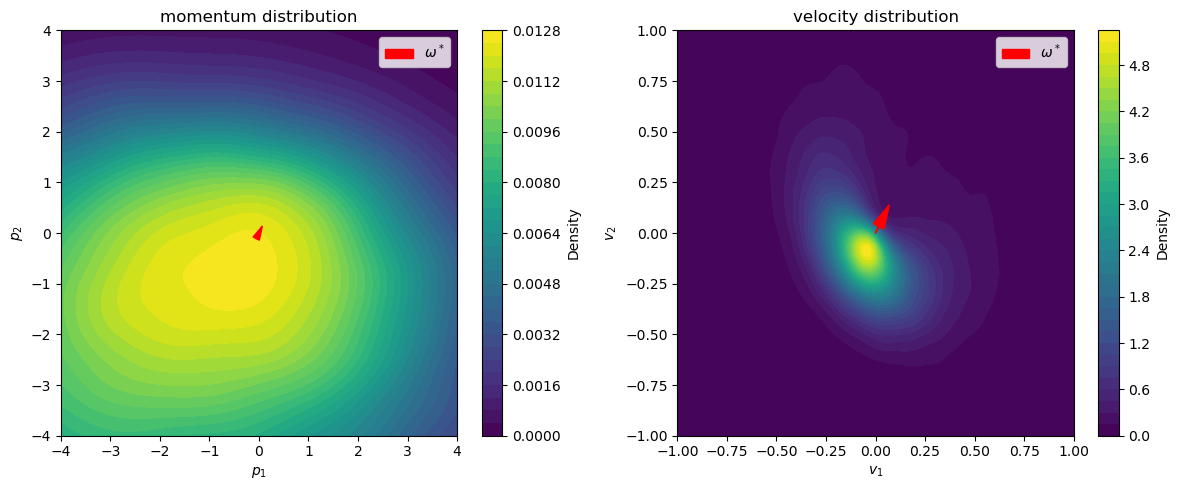

In [18]:
# Plot both p and v distributions on two subfigures
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from scipy.stats import gaussian_kde
import numpy as np

# Convert to numpy
p_np = p.detach().cpu().numpy()
v_np = v.detach().cpu().numpy()

# --- Define separate grids for p and v ---
grid_size = 150

# Momentum grid: [-4, 4]^2
p_xgrid = np.linspace(-4, 4, grid_size)
p_ygrid = np.linspace(-4, 4, grid_size)
p_xx, p_yy = np.meshgrid(p_xgrid, p_ygrid)
p_grid_points = np.vstack([p_xx.ravel(), p_yy.ravel()])

# Velocity grid: [-1, 1]^2
v_xgrid = np.linspace(-1, 1, grid_size)
v_ygrid = np.linspace(-1, 1, grid_size)
v_xx, v_yy = np.meshgrid(v_xgrid, v_ygrid)
v_grid_points = np.vstack([v_xx.ravel(), v_yy.ravel()])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- First subplot: p distribution ---
# KDE for p
kde_p = gaussian_kde(p_np.T)
zz_p = kde_p(p_grid_points).reshape(p_xx.shape)
cf_p = axs[0].contourf(p_xx, p_yy, zz_p, levels=40)
plt.colorbar(cf_p, ax=axs[0], label="Density")
w_np = w.detach().cpu().numpy()
arrow_scale = 0.7
axs[0].arrow(0, 0, arrow_scale * w_np[0], arrow_scale * w_np[1],
             head_width=0.14, head_length=0.28, fc='r', ec='r',
             length_includes_head=True, label=r'$\omega^*$')
# Proxy for legend
proxy_arrow = FancyArrow(0, 0, 0.5, 1.0, width=0.02, color='r')
axs[0].legend([proxy_arrow], [r'$\omega^*$'], loc='upper right')
axs[0].set_xlim([-4, 4])
axs[0].set_ylim([-4, 4])
axs[0].set_xlabel("$p_1$")
axs[0].set_ylabel("$p_2$")
axs[0].set_title("momentum distribution")

# --- Second subplot: v distribution ---
# KDE for v
kde_v = gaussian_kde(v_np.T)
zz_v = kde_v(v_grid_points).reshape(v_xx.shape)
cf_v = axs[1].contourf(v_xx, v_yy, zz_v, levels=40)
plt.colorbar(cf_v, ax=axs[1], label="Density")
axs[1].arrow(0, 0, arrow_scale * w_np[0], arrow_scale * w_np[1],
             head_width=0.06, head_length=0.12, fc='r', ec='r',
             length_includes_head=True, label=r'$\omega^*$')
axs[1].legend([proxy_arrow], [r'$\omega^*$'], loc='upper right')
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([-1, 1])
axs[1].set_xlabel("$v_1$")
axs[1].set_ylabel("$v_2$")
axs[1].set_title("velocity distribution")

plt.tight_layout()
plt.show()

##### Dimension dependancy test

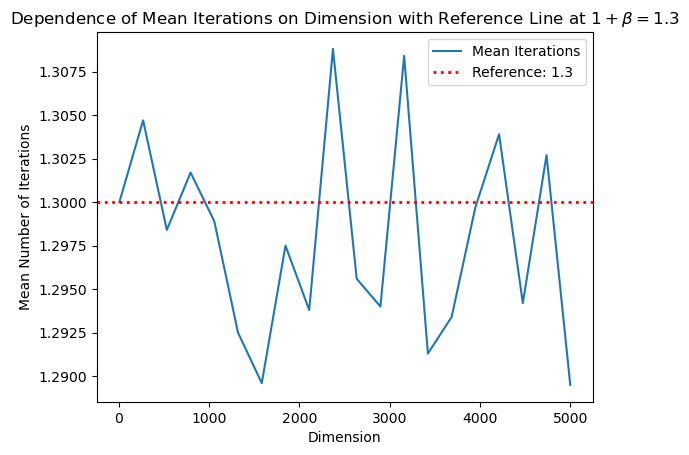

In [19]:
n_dims = 20
dims = torch.linspace(5, 5000, n_dims)
batch_size = 10000
mean_iter = []

for d in dims:
    d = int(d.item())
    w = torch.zeros(d)
    w[0] = 0.3
    M = torch.eye(d)
    mean_iter.append(momentum_exact_sampler(M, w, batch_size, True)[1])

plt.plot(dims, mean_iter, label="Mean Iterations")
plt.axhline(1.3, color='r', linestyle=':', linewidth=2, label="Reference: 1.3")
plt.xlabel("Dimension")
plt.ylabel("Mean Number of Iterations")
plt.title(r"Dependence of Mean Iterations on Dimension with Reference Line at $1+\beta = 1.3$")
plt.legend()
plt.show()

## 2 - Hamiltonian trajectories for Randers geodesics

### 2.1. Euler solver

### 2.2. Implicit solver

In [ ]:
class ImplicitLeapfrogIntegrator(torch.nn.Module):
    def __init__(
        self,
        randers_cometric : DualRandersMetrics, 
        l : int, 
        gamma : float, 
        N_fx : int,  
        beta_0: float = 1,
        threshold_fx: float = 1e-5,
    ):
        super().__init__()
        self.randers_cometric = randers_cometric
        self.l = l
        self.gamma = gamma
        self.N_fx = N_fx
        self.beta_0_sqrt = beta_0**0.5
        self.threshold_fx = threshold_fx

        self._dH_dz_ = torch.func.jacrev(self.H_base, argnums=0)
        self._dH_dv = torch.func.jacrev(self.H_base, argnums=1)
        self.dH_dz = lambda z, v: self._dH_dz_(z, v).sum(1)
        self.dH_dv = lambda z, v: self._dH_dv(z, v).sum(1)

        self.log2pi = torch.log(torch.tensor(2 * 3.1415927410125732))
    
    def U(self, z: Tensor) -> Tensor : 
        """_summary_

        Args:
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        b = z.shape[0]
        return torch.zeros(b)
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        """Compute Kinetic energy in the randers case 
        K(p) = (
        1/2 * F_z^*(p)^2
        - (d+1)/2 * log(1-g^*_inv(omega^*))
        -1/2 * logdet G^* + d/2 * log 2pi
        )

        Args:
            p (Tensor): Momentum vector of shape (n_batch, d)
            z (Tensor): Position vector of shape (n_batch, d)

        Returns:
            Tensor: Kinetic energy of shape (n_batch,)
        """
        d = z.shape[1]

        metric_term = 0.5 * self.randers_cometric(z, p) ** 2
        G_star = self.randers_cometric.G_star(z)          
        w_star = self.randers_cometric.omega_star(z)     
        L = torch.linalg.cholesky(G_star)
        x = torch.cholesky_solve(w_star.unsqueeze(-1), L).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", w_star, x)
        logdet_G = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)

        return (
            metric_term
            - 0.5 * (d + 1) * torch.log1p(-alpha)
            - 0.5 * logdet_G
            + 0.5 * d * self.log2pi
        )

    def H_base(self, z: Tensor, v: Tensor) -> Tensor:
        """
        Compute the Hamiltonian H(z,v) = U(z) + K(v)

        Parameters
        ----------
        z : Tensor (b,d)
            The position.
        v : Tensor (b,d)
            The velocity.

        Returns
        -------
        Tensor (b,)
        """
        return self.U(z) + self.K(v, z)

    def tempering(self, k) -> float:
        """
        Compute the tempering coefficient at step k.

        Parameters
        ----------
        k : int
            The current step.

        Returns
        -------
        beta_k : float
            The tempering coefficient at step k.
        """
        # NO TEMPERING
        return 1.

    def get_v_half(self, z: Tensor, v: Tensor) -> Tensor:
        """
        Solves the fixed point equation for the velocity.
        v_half = v - gamma/2 * dH_dz(z, v_half)

        Parameters
        ----------
        z : Tensor (b,d)
            The position.
        v : Tensor (b,d)
            The velocity.

        Returns
        -------
        v_half : Tensor (b,d)
            The half step velocity.
        """
        v_half = v.clone()
        for k in range(self.N_fx):
            v_half_ = v_half - self.gamma * self.dH_dz(z, v_half) / 2
            if (v_half_ - v_half).abs().max() < self.threshold_fx:
                v_half = v_half_
                break
            v_half = v_half_
        return v_half

    def get_z_new(self, z: Tensor, v_half: Tensor) -> Tensor:
        """
        Solves the fixed point equation for the position.
        z_new = z + gamma/2 * ( dH_dv(z, v_half) + dH_dv(z_new,v_half) )

        Parameters
        ----------
        z : Tensor (b,d)
            The position.
        v_half : Tensor (b,d)
            The half step velocity.

        Returns
        -------
        z_new : Tensor (b,d)
            The new position.
        """
        z_new = z.clone()
        for k in range(self.N_fx):
            z_new_ = (
                z_new + self.gamma * (self.dH_dv(z, v_half) + self.dH_dv(z_new, v_half)) / 2
            )
            if (z_new_ - z_new).abs().max() < self.threshold_fx:
                z_new = z_new_
                break
            z_new = z_new_
        return z_new

    def leapfrog_step(self, z: Tensor, v: Tensor) -> tuple[Tensor, Tensor]:
        """
        Perform a single leapfrog step.

        Parameters
        ----------
        z : Tensor (b,d)
            The initial position.
        v : Tensor (b,d)
            The initial velocity.

        Returns
        -------
        z_new : Tensor (b,d)
            The new position.
        v_new : Tensor (b,d)
            The new velocity.
        """
        v_half = self.get_v_half(z, v)
        z_new = self.get_z_new(z, v_half)
        v_new = v_half - self.gamma * self.dH_dz(z_new, v_half) / 2
        return z_new, v_new

    def leapfrog(self, z: Tensor, v: Tensor, return_traj: bool = False) -> Tensor:
        """
        Perform l leapfrog steps with tempering of the momentum.

        Parameters
        ----------
        z : Tensor (b,d)
            The initial position.
        v : Tensor (b,d)
            The initial velocity.
        return_traj : bool
            If True, it returns the trajectory of the samples over the l leapfrog steps.

        Returns
        -------
        z_new : Tensor (b,d)
            The new position.
        v_new : Tensor (b,d)
            The new velocity.
        or
        (Tensor (b,l+1,d), Tensor (b,l+1,d))
            The trajectory of the positions and velocities over the l leapfrog steps.
        """
        z_new, v_new = z.clone(), v.clone()
        if return_traj:
            traj_q = [z_new.clone()]
            traj_p = [v_new.clone()]
        beta_k_minus_1_sqrt = self.beta_0_sqrt
        for k in range(self.l):
            z_new, v_new = self.leapfrog_step(z_new, v_new)
            beta_k_sqrt = self.tempering(k)
            v_new = (beta_k_minus_1_sqrt / beta_k_sqrt) * v_new
            beta_k_minus_1_sqrt = beta_k_sqrt

            if return_traj:
                traj_q.append(z_new.clone())
                traj_p.append(v_new.clone())

        if return_traj:
            traj_q = torch.stack(traj_q, dim=1)
            traj_p = torch.stack(traj_p, dim=1)
            return traj_q, traj_p

        return z_new, v_new

    def forward(self, z_0 : Tensor, v_0 : Tensor) -> tuple[Tensor, Tensor] : 
        """Integrates the Hamiltonian equation with implicit leapfrog solver.

        Parameters
        ----------
        z_0 : Tensor (b,d)
            The initial position of the first state.
        v0 : Tensor (b,d)
            The initial momentum of the first state.

        Returns
        -------
        traj : Tensor (b,l+1,d), Tensor (b,l+1,d)
            The trajectorie of position and momentum over l leapfrog steps.
        """

        traj = self.leapfrog(z_0, v_0, return_traj=True)
        return traj[0], traj[1]


In [21]:
randers_cometric = randers_cometric # Defined previously
l = 10
N_fx = 6
gamma = 0.1
solver = ImplicitLeapfrogIntegrator(
    randers_cometric= randers_cometric, 
    l = l,
    gamma = gamma,
    N_fx= N_fx
)

In [22]:
z_0 = torch.tensor([[0.,1.]])
v_0 = torch.tensor([[0.05,0.]])
traj = solver(z_0, v_0)

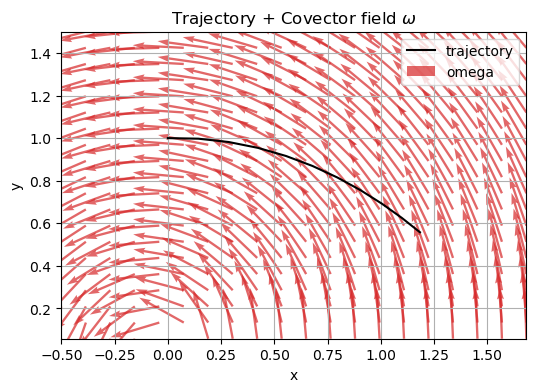

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

# ---- Trajectory ----
positions = traj[0][0].detach().numpy()  # shape (l+1, d)
ax.plot(positions[:, 0], positions[:, 1], color='black', label="trajectory")

# ---- Define plotting window from trajectory ----
xmin, xmax = positions[:, 0].min(), positions[:, 0].max()
ymin, ymax = positions[:, 1].min(), positions[:, 1].max()

# Add margin
margin = 0.5
xmin -= margin; xmax += margin
ymin -= margin; ymax += margin

# ---- Grid adapted to trajectory frame ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Trajectory + Covector field $\omega$")
ax.grid(True)
ax.legend()

plt.show()

### 2.3. Explicit solver

In [ ]:
class ExplicitLeapfrogIntegrator(torch.nn.Module):
    def __init__(
        self,
        randers_cometric : DualRandersMetrics, 
        l : int, 
        gamma : float, 
        omega : float, 
        beta_0: float = 1,
    ):
        super().__init__()
        self.randers_cometric = randers_cometric
        self.l = l
        self.gamma = gamma
        self.omega = omega
        self.beta_0_sqrt = beta_0**0.5

        c = torch.Tensor([2 * self.omega * self.gamma]).cos()
        s = torch.Tensor([2 * self.omega * self.gamma]).sin()
        self.register_buffer("c", c, persistent=False)
        self.register_buffer("s", s, persistent=False)

        self._dH_dz_ = torch.func.jacrev(self.H_base, argnums=0)
        self._dH_dv = torch.func.jacrev(self.H_base, argnums=1)
        self.dH_dz = lambda z, v: self._dH_dz_(z, v).sum(1)
        self.dH_dv = lambda z, v: self._dH_dv(z, v).sum(1)

        self.log2pi = torch.log(torch.tensor(2 * 3.1415927410125732))
    
    def U(self, z: Tensor) -> Tensor : 
        """_summary_

        Args:
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        b = z.shape[0]
        return torch.zeros(b)
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        """Compute Kinetic energy in the randers case 
        K(p) = (
        1/2 * F_z^*(p)^2
        - (d+1)/2 * log(1-g^*_inv(omega^*))
        -1/2 * logdet G^* + d/2 * log 2pi
        )

        Args:
            p (Tensor): Momentum vector of shape (n_batch, d)
            z (Tensor): Position vector of shape (n_batch, d)

        Returns:
            Tensor: Kinetic energy of shape (n_batch,)
        """
        d = z.shape[1]

        metric_term = 0.5 * self.randers_cometric(z, p) ** 2
        G_star = self.randers_cometric.G_star(z)          
        w_star = self.randers_cometric.omega_star(z)     
        L = torch.linalg.cholesky(G_star)
        x = torch.cholesky_solve(w_star.unsqueeze(-1), L).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", w_star, x)
        logdet_G = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)

        return (
            metric_term
            - 0.5 * (d + 1) * torch.log1p(-alpha)
            - 0.5 * logdet_G
            + 0.5 * d * self.log2pi
        )

    def H_base(self, z: Tensor, v: Tensor) -> Tensor:
        """
        Compute the Hamiltonian H(z,v) = U(z) + K(v)

        Parameters
        ----------
        z : Tensor (b,d)
            The position.
        v : Tensor (b,d)
            The velocity.

        Returns
        -------
        Tensor (b,)
        """
        return self.U(z) + self.K(v, z)

    def tempering(self, k) -> float:
        """
        Compute the tempering coefficient at step k.

        Parameters
        ----------
        k : int
            The current step.

        Returns
        -------
        beta_k : float
            The tempering coefficient at step k.
        """
        # NO TEMPERING
        return 1.

    def leapfrog_step(
        self, z_0: Tensor, v_0: Tensor, z_1: Tensor, v_1: Tensor
    ) -> tuple[Tensor, Tensor, Tensor, Tensor]:
        """
        Leapfrog step for the augmented Hamiltonian.
        Pseudo code in `Introducing an Explicit Symplectic Integration Scheme for Riemannian Manifold Hamiltonian Monte Carlo`
        by Cobb et Baydin et al (2019).

        Parameters
        ----------
        z_0 : Tensor (b,d)
            The position of the first state.
        v_0 : Tensor (b,d)
            The velocity of the first state.
        z_1 : Tensor (b,d)
            The position of the second state.
        v_1 : Tensor (b,d)
            The velocity of the second state.

        Returns
        -------
        z_0_new : Tensor (b,d)
            The new position of the first state.
        v_0_new : Tensor (b,d)
            The new velocity of the first state.
        z_1_new : Tensor (b,d)
            The new position of the second state.
        v_1_new : Tensor (b,d)
            The new velocity of the second state.
        """
        v_0_new = v_0 - self.gamma / 2 * self.dH_dz(z_0, v_1)
        z_1_new = z_1 + self.gamma / 2 * self.dH_dv(z_0, v_1)
        v_1_new = v_1 - self.gamma / 2 * self.dH_dz(z_1_new, v_0)
        z_0_new = z_0 + self.gamma / 2 * self.dH_dv(z_1_new, v_0)

        z_0_new = (
            z_0_new + z_1_new + self.c * (z_0_new - z_1_new) + self.s * (v_0_new - v_1_new)
        ) / 2
        v_0_new = (
            v_0_new + v_1_new - self.s * (z_0_new - z_1_new) + self.c * (v_0_new - v_1_new)
        ) / 2
        z_1_new = (
            z_0_new + z_1_new - self.c * (z_0_new - z_1_new) - self.s * (v_0_new - v_1_new)
        ) / 2
        v_1_new = (
            v_0_new + v_1_new + self.s * (z_0_new - z_1_new) - self.c * (v_0_new - v_1_new)
        ) / 2

        v_1_new = v_1_new - self.gamma / 2 * self.dH_dz(z_1_new, v_0_new)
        z_0_new = z_0_new + self.gamma / 2 * self.dH_dv(z_1_new, v_0_new)
        v_0_new = v_0_new - self.gamma / 2 * self.dH_dz(z_0_new, v_1_new)
        z_1_new = z_1_new + self.gamma / 2 * self.dH_dv(z_0_new, v_1_new)

        return z_0_new, v_0_new, z_1_new, v_1_new

    def leapfrog(
        self, z_0: Tensor, v0: Tensor, z_1: Tensor, v1: Tensor, return_traj: bool = False
    ) -> tuple[Tensor, Tensor, Tensor, Tensor]:
        """
        Perform l leapfrog steps with tempering of the momentum.

        Parameters
        ----------
        z_0 : Tensor (b,d)
            The initial position of the first state.
        v0 : Tensor (b,d)
            The initial velocity of the first state.
        z_1 : Tensor (b,d)
            The initial position of the second state.
        v1 : Tensor (b,d)
            The initial velocity of the second state.
        return_traj : bool
            If True, it returns the trajectory of the samples over the l leapfrog steps.

        Returns
        -------
        z_l_0 : Tensor (b,d)
            The new position of the first state.
        v_l_0 : Tensor (b,d)
            The new velocity of the first state.
        z_l_1 : Tensor (b,d)
            The new position of the second state.
        v_l_1 : Tensor (b,d)
            The new velocity of the second state.
        or
        (Tensor (b,l+1,d), Tensor (b,l+1,d), Tensor (b,l+1,d), Tensor (b,l+1,d))
            The trajectory of the positions and velocities over the l leapfrog steps.
        """
        z_l_0, v_l_0, z_l_1, v_l_1 = z_0.clone(), v0.clone(), z_1.clone(), v1.clone()
        if return_traj:
            traj_q_0 = [z_l_0.clone()]
            traj_p_0 = [v_l_0.clone()]
            traj_q_1 = [z_l_1.clone()]
            traj_p_1 = [v_l_1.clone()]
        beta_k_minus_1_sqrt = self.beta_0_sqrt
        for k in range(self.l):
            z_l_0, v_l_0, z_l_1, v_l_1 = self.leapfrog_step(z_l_0, v_l_0, z_l_1, v_l_1)
            beta_k_sqrt = self.tempering(k)
            v_l_0 = (beta_k_minus_1_sqrt / beta_k_sqrt) * v_l_0
            v_l_1 = (beta_k_minus_1_sqrt / beta_k_sqrt) * v_l_1
            beta_k_minus_1_sqrt = beta_k_sqrt

            if return_traj:
                traj_q_0.append(z_l_0.clone())
                traj_p_0.append(v_l_0.clone())
                traj_q_1.append(z_l_1.clone())
                traj_p_1.append(v_l_1.clone())

        if return_traj:
            traj_q_0 = torch.stack(traj_q_0, dim=1)
            traj_p_0 = torch.stack(traj_p_0, dim=1)
            traj_q_1 = torch.stack(traj_q_1, dim=1)
            traj_p_1 = torch.stack(traj_p_1, dim=1)
            return traj_q_0, traj_p_0, traj_q_1, traj_p_1

        return z_l_0, v_l_0, z_l_1, v_l_1

    def forward(self, z_0 : Tensor, v_0 : Tensor) -> tuple[Tensor, Tensor] : 
        """Integrates the Hamiltonian equation with explicit leapfrog solver.

        Parameters
        ----------
        z_0 : Tensor (b,d)
            The initial position of the first state.
        v0 : Tensor (b,d)
            The initial momentum of the first state.

        Returns
        -------
        traj : Tensor (b,l+1,d), Tensor (b,l+1,d)
            The trajectorie of position and momentum over l leapfrog steps.
        """

        traj = self.leapfrog(z_0, v_0, z_0, v_0, return_traj=True)
        return traj[0], traj[1]


In [40]:
randers_cometric = randers_cometric # Defined previously
l = 10
omega = 1.
gamma = 0.1
solver = ExplicitLeapfrogIntegrator(
    randers_cometric= randers_cometric, 
    l = l,
    gamma = gamma,
    omega = omega,
)

In [41]:
z_0 = torch.tensor([[0.,1.]])
v_0 = torch.tensor([[0.05,0.]])
traj = solver(z_0, v_0)

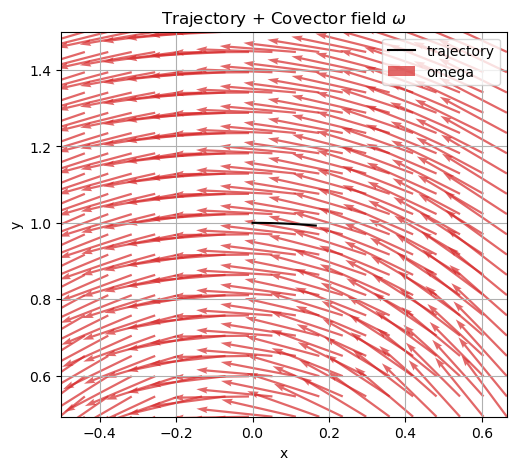

In [42]:
fig, ax = plt.subplots(figsize=(6, 5))

# ---- Trajectory ----
positions = traj[0][0].detach().numpy()  # shape (l+1, d)
ax.plot(positions[:, 0], positions[:, 1], color='black', label="trajectory")

# ---- Define plotting window from trajectory ----
xmin, xmax = positions[:, 0].min(), positions[:, 0].max()
ymin, ymax = positions[:, 1].min(), positions[:, 1].max()

# Add margin
margin = 0.5
xmin -= margin; xmax += margin
ymin -= margin; ymax += margin

# ---- Grid adapted to trajectory frame ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Trajectory + Covector field $\omega$")
ax.grid(True)
ax.legend()

plt.show()

## 3- Tests for FHMC algorithm with difference acceptation rates

## 3.1. FHMC without rejection (or Finsler Brownian motion ?)

### 3.1.1. Using implicit sampler

### 3.1.2 Using explicit sampler

In [85]:
class ExplicitFHMC(ExplicitRHMCSampler):

    def __init__(
        self,
        randers_cometric : DualRandersMetrics, 
        l : int, 
        gamma : float, 
        omega : float, 
        N_run : int, 
        momentum_sampler : str = "exact", #"exact" or "mcmc"
        momentum_N : int = 50, 
        momentum_sigma : float = 0.1, 
        bounds : float = 1e3, 
        std_0 : float = 1.0, 
        beta_0 : float = 1.0, 
        pbar : bool = False, 
        skip_acceptance = False
    ):
        super().__init__(
            randers_cometric.base_cometric, 
            l,
            gamma, 
            omega, 
            N_run, 
            std_0, 
            bounds, 
            beta_0, 
            pbar, 
            skip_acceptance
        )
        self.momentum_sampler = momentum_sampler
        self.momentum_N = momentum_N
        self.momentum_sigma = momentum_sigma
        self.randers_cometric = randers_cometric

    # def U(self, z: Tensor) -> Tensor:
    #     """
    #     Gaussian potential energy: negative log-density of N(mu, Sigma)

    #     Args:
    #         z: Tensor of shape (n_batch, d)

    #     Returns:
    #         Tensor of shape (n_batch,)
    #     """
    #     d = z.shape[1]
    #     return 0.5 * (z * z).sum(dim=-1) + 0.5 * d * self.log2pi

    def U(self, z: Tensor) -> Tensor:
        """
        Ring-shaped potential on R^2:
            pi(z) ∝ exp(-0.5 * kappa * (||z|| - r0)^2)

        Required attributes:
            self.kappa: positive scalar
            self.r0: nonnegative scalar
        """
        r0 = 10.0
        kappa = 0.01
        r = torch.linalg.norm(z, dim=-1)
        return 0.5 * kappa * (r - r0) ** 2
    

    def K(self, p: Tensor, z: Tensor) -> Tensor:
        """Compute Kinetic energy in the randers case 
        K(p) = (
        1/2 * F_z^*(p)^2
        - (d+1)/2 * log(1-g^*_inv(omega^*))
        -1/2 * logdet G^* + d/2 * log 2pi
        )

        Args:
            p (Tensor): Momentum vector of shape (n_batch, d)
            z (Tensor): Position vector of shape (n_batch, d)

        Returns:
            Tensor: Kinetic energy of shape (n_batch,)
        """
        d = z.shape[1]

        metric_term = 0.5 * self.randers_cometric(z, p) ** 2
        G_star = self.randers_cometric.G_star(z)          
        w_star = self.randers_cometric.omega_star(z)     
        L = torch.linalg.cholesky(G_star)
        x = torch.cholesky_solve(w_star.unsqueeze(-1), L).squeeze(-1)
        alpha = torch.einsum("bi,bi->b", w_star, x)
        logdet_G = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)

        return (
            metric_term
            - 0.5 * (d + 1) * torch.log1p(-alpha)
            - 0.5 * logdet_G
            + 0.5 * d * self.log2pi
        )


    def momentum_mcmc_sampler(self, p0 : Tensor, z : torch.Tensor, return_acceptance : bool = False )-> Tensor :
        """
        Performs l steps of a symmetric random walk Metropolis sampler for the momentum distribution
        Args:
            z0 (Tensor): Initial value/batch of values of shape (batch_size, d).
            l (int): Number of Metropolis steps to perform.
            sigma (float): Proposal standard deviation (step size of the Gaussian random walk).
            w (Tensor): Randers covector of shape (d,).

        Returns:
            Tensor: Final sample(s) after l Metropolis steps, of shape (batch_size, d).
        """
        p = p0.clone()
        b, d = p.shape
        n_accept = 0
        n_total = 0
        
        M = self.randers_cometric.G_star(z)
        L = torch.linalg.cholesky(M)
        
        for _ in range(self.momentum_N): 
            epsilon = torch.randn(b, d, 1, device=z.device)
            step_unsq = torch.linalg.solve_triangular(L, epsilon, upper=False)
            prop = p + self.momentum_sigma * step_unsq.squeeze(-1)
    
            log_alpha = self.H_base(z, p) - self.H_base(z, prop)   
            u = torch.log(torch.rand(b, device=z.device))  
            mask = (u < log_alpha)  

            n_accept += mask.sum().item()
            n_total += b

            p = torch.where(mask.unsqueeze(1), prop, p)

        if return_acceptance:
            acceptance_rate = n_accept / n_total if n_total > 0 else 0.0
            return p, acceptance_rate
        else:
            return p

    def sample_momentum_mcmc(self, z: Tensor) -> Tensor:
        """ Sample from the Randers-Gaussian distribution 
        propto exp(-0.5(|p|_g+w^Tp)^2) 
        using Symetric Random Walk Metropolis Hastings

        Parameters
        ----------
        z : Tensor (b,d)
            The position.

        Returns
        -------
        p : Tensor (b,d)
            The sampled momentum.
        """
        p_init = torch.randn_like(z)
        p, acc = self.momentum_mcmc_sampler(p_init, z, return_acceptance= True)
        if acc < 0.05 or acc > 0.95:
            warnings.warn(f"Metropolis momentum sampler has degenerate acceptance rate: {acc:.4f}")
        return p

    def moebius_transform(self, u: Tensor, mu: Tensor, rho: Tensor, M: Tensor) -> Tensor:
        """
        Applies a Möbius transformation relevant to sampling on Riemannian manifolds.

        Args:
            u (Tensor): Input points of shape (batch_size, d).
            mu (Tensor): Mean direction vector of shape (batch_size, d).
            rho (Tensor): Scalar parameter controlling rotation/stretch (batch_size,).
            M (Tensor): Symmetric positive definite matrix (covariance or metric) of shape (batch_size, d, d).

        Returns:
            Tensor: Transformed points of shape (batch_size, d) after applying the Möbius transformation.
        """
        inner_prod = torch.einsum('bi,bij,bj->b', u, M, mu).unsqueeze(-1)  # (B, 1)

        rho_ = rho.unsqueeze(-1)  # (B, 1)

        num = (1 - rho_**2) * (u + rho_ * mu)
        den = 1 + 2 * rho_ * inner_prod + rho_**2

        return num / den + rho_ * mu


    def riemann_sphere_uniform_sampler(self, L: Tensor) -> Tensor:
        """
        Uniformly samples points from the unit sphere with respect to the induced metric defined by L on R^d.

        Args:
            L (Tensor): Cholesky factor of a positive-definite matrix of shape (batch_size, d, d)

        Returns:
            Tensor: An array of shape (batch_size, d) containing batch_size points uniformly sampled on the
            L-induced unit sphere.
        """
        batch_size, d, _ = L.shape

        # Sample standard Gaussian
        z = torch.randn(batch_size, d, device=L.device, dtype=L.dtype)

        # Normalize to Euclidean unit sphere
        z_unit = z / torch.linalg.norm(z, dim=-1, keepdim=True)

        # Solve L^T v = z_unit  (batched)
        v = torch.linalg.solve_triangular(
            L.transpose(-1, -2),              
            z_unit.unsqueeze(-1),             
            upper=True
        ).squeeze(-1)                     

        return v



    def sample_momentum_exact(self, z : Tensor) -> Tensor:
        """
        Samples the initial momentum for the FHMC algorithm, exactly according to distribution induced by kinetic energy.

        Args:
            M (Tensor): The symmetric positive definite metric tensor of shape (d, d).
            w (Tensor): The potential vector of length d, defining the linear drift in momentum space.
            batch_size (int, optional): Number of independent momentum samples to generate. Defaults to 1.
            return_stats (bool, optional): If True, also returns the mean number of proposal iterations per sample. Defaults to False.

        Returns:
            Tensor: Sampled momentum tensor of shape (batch_size, d).
            float (optional): If return_stats is True, average number of iterations per sample is also returned.
        """
        batch_size, d = z.shape

        # Pre-computations
        M = self.randers_cometric.G_star(z)
        M_inv = torch.linalg.inv(M)
        w = self.randers_cometric.omega_star(z)
        L = torch.linalg.cholesky(M) 
        beta = torch.sqrt(torch.einsum('bi,bij,bj->b', w, M_inv, w))
        mu = -torch.matmul(M_inv, w.unsqueeze(-1)).squeeze(-1) / beta.unsqueeze(-1)
        rho = beta / (1 + torch.sqrt(1 - beta**2))
        
        # Initialize containers for the accepted directions u'
        final_u_prime = torch.zeros((batch_size, d), device=z.device, dtype=z.dtype)
        accepted_mask = torch.zeros(batch_size, dtype=torch.bool, device=z.device)
        
        # Acceptance-Rejection for the direction u'
        while not accepted_mask.all():
            active_indices = torch.where(~accepted_mask)[0]
            num_to_sample = len(active_indices)
            
            v_subset = self.riemann_sphere_uniform_sampler(L[active_indices])
            
            # Moebius transform on the subset
            u_subset = self.moebius_transform(
                v_subset, 
                mu[active_indices], 
                rho[active_indices], 
                M[active_indices]
            )
            
           # Bernoulli accept-reject
            p = (1 - beta[active_indices]) / (1 + torch.sum(u_subset * w[active_indices], dim=-1))
            alpha = torch.rand(num_to_sample, device=z.device) <= p
            
            if alpha.any():
                just_accepted_indices = active_indices[alpha]
                final_u_prime[just_accepted_indices] = u_subset[alpha]
                accepted_mask[just_accepted_indices] = True
                
        # Sample radius r 
        s = torch.randn(batch_size, d, device=z.device).norm(dim=-1)
        r = s / (1 + torch.sum(final_u_prime * w, dim=-1))
        
        # Final momentum q = r * u'
        final_q = r.unsqueeze(-1) * final_u_prime
        
        return final_q

    def sample_momentum(self, z: Tensor) -> Tensor:
        """
        Sample the momentum at position z according to the configured momentum sampler.

        Parameters
        ----------
        z : Tensor
            The position(s) at which to sample the momentum. Shape (batch_size, d).

        Raises
        ------
        ValueError
            If the provided momentum_sampler string is not one of ['exact', 'mcmc'].

        Returns
        -------
        Tensor
            The sampled momentum at each position in z. Shape (batch_size, d).
        """
   
        if self.momentum_sampler == "exact" : 
            return self.sample_momentum_exact(z)
        elif self.momentum_sampler == "mcmc" : 
            return self.sample_momentum_mcmc(z)
        else : 
            raise ValueError(f"Invalid momentum_sampler argument: {self.momentum_sampler}. Must be one of ['exact', 'mcmc'].")


In [76]:
eta = 0.9
alpha = torch.Tensor([0.1])
#cometric = RingCometricBump(alpha)
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

l = 1
gamma = 0.01
omega = 10.
N_run = 100

sampler_brownian_explicit = ExplicitFHMC(
    randers_cometric,
    l, 
    gamma, 
    omega, 
    N_run, 
    pbar = True,
    skip_acceptance = True
    )

In [77]:
traj = sampler_brownian_explicit.sample(
    z_0 = torch.tensor([[0., 1.]]*100),
    return_traj= True, 
    progress=True
)

Sampling: 100%|██████████| 100/100 [00:02<00:00, 34.25steps/s, acceptance_rate=1]


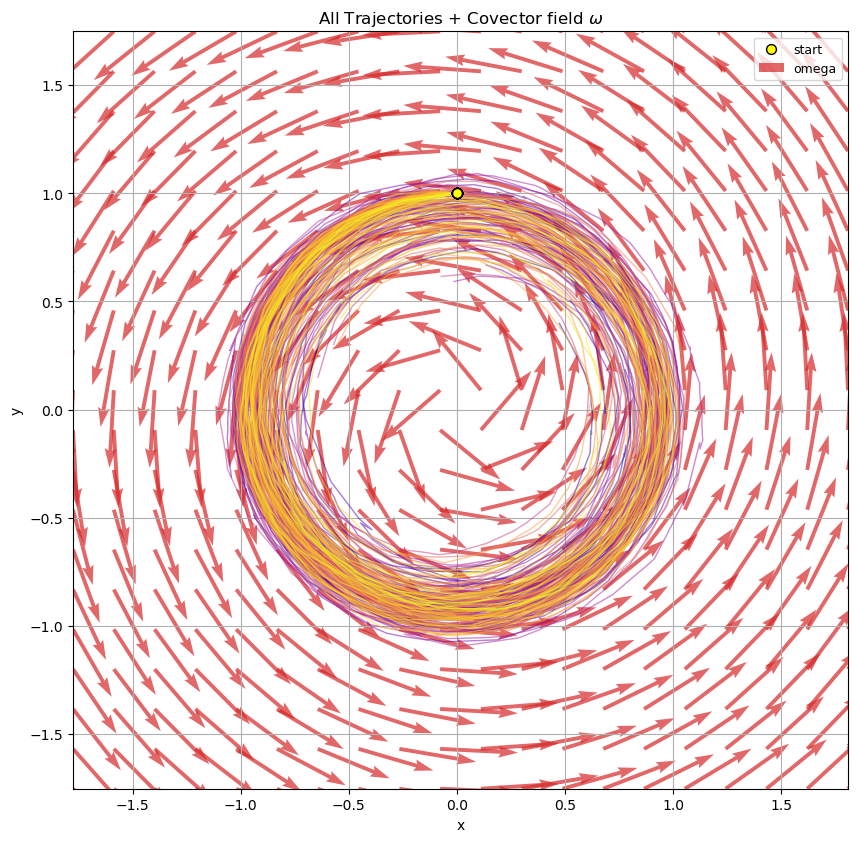

In [78]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True)
ax.legend(loc="upper right", fontsize=9)

plt.show()

## 3.2. FHMC : acceptation ratio as likelihood ratio

### 3.1.1 Using implicit sampler

### 3.1.2 Using explicit sampler

In [86]:
eta = 0.5
alpha = torch.Tensor([0.1])
#cometric = RingCometricBump(alpha)
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)
l = 5
gamma = 0.01
omega = 10.
N_run = 1000


sampler_fhmc1 = ExplicitFHMC(
    randers_cometric,
    l, 
    gamma, 
    omega, 
    N_run, 
    pbar = True
    )

In [87]:
traj, acc = sampler_fhmc1.sample(
    z_0 = torch.tensor([[0.,1.]]*100),
    return_traj= True, 
    return_acceptance= True,
    progress = True
)
print(f"Acceptance rate: {acc:.4f}")

Sampling: 100%|██████████| 1000/1000 [01:46<00:00,  9.40steps/s, acceptance_rate=0.965]

Acceptance rate: 0.9647


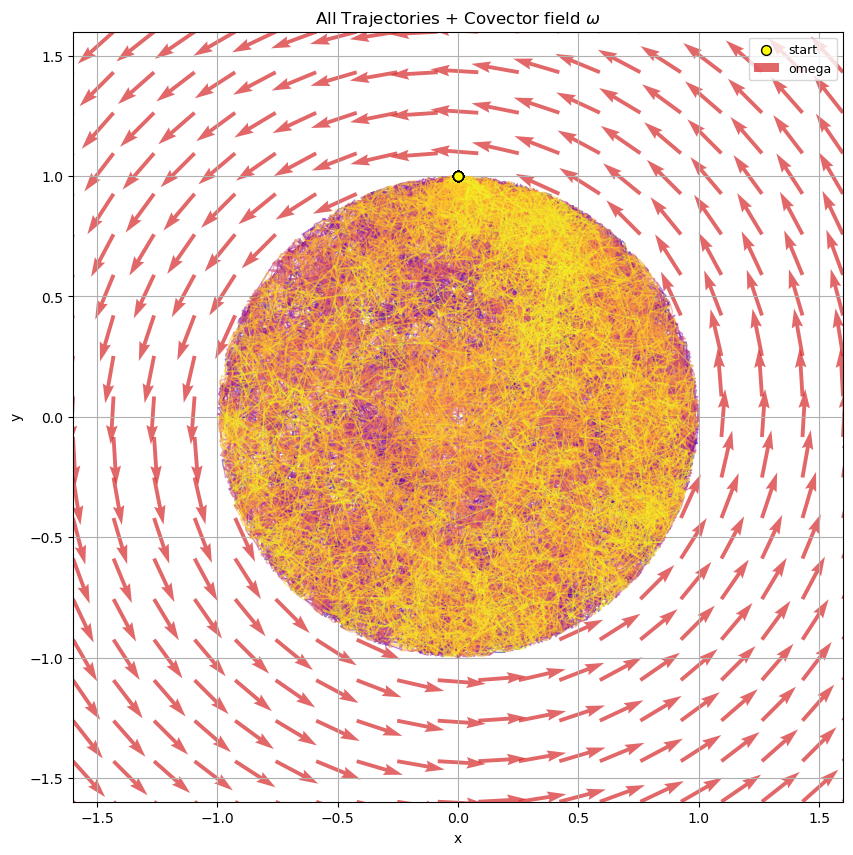

In [90]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True)
ax.legend(loc="upper right", fontsize=9)

plt.show()

In [37]:
eta = 0.5
alpha = torch.Tensor([0.1])
cometric = RingCometricRect(alpha)
#cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)
l = 1
gamma = 0.01
omega = 10.
N_run = 1000


sampler_fhmc2 = ExplicitFHMC(
    randers_cometric,
    l, 
    gamma, 
    omega, 
    N_run, 
    pbar = True
    )

In [38]:
traj, acc = sampler_fhmc2.sample(
    z_0 = torch.tensor([[0.,1.]]*1000),
    return_traj= True, 
    return_acceptance= True,
    progress = True
)
print(f"Acceptance rate: {acc:.4f}")

Sampling:   3%|▎         | 31/1000 [00:06<03:36,  4.48steps/s, acceptance_rate=0.54] 


_LinAlgError: linalg.cholesky: (Batch element 423): The factorization could not be completed because the input is not positive-definite (the leading minor of order 2 is not positive-definite).

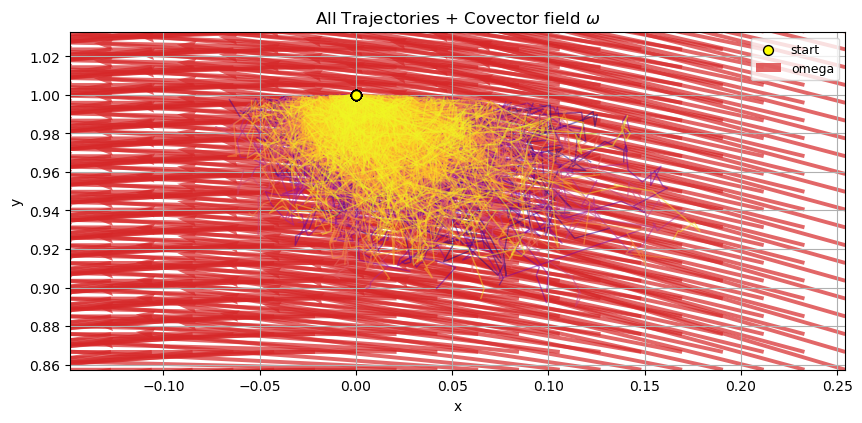

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# ---- Trajectories ----
positions = traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)
if isinstance(positions, tuple):
    positions = positions[2]  # fallback for old traj structure
positions = np.asarray(positions)

# Automatically determine plotting window based on trajectory data, with some margin
margin = 0.3  # as ratio of span
x_min_traj = np.nanmin(positions[..., 0])
x_max_traj = np.nanmax(positions[..., 0])
y_min_traj = np.nanmin(positions[..., 1])
y_max_traj = np.nanmax(positions[..., 1])

x_span = x_max_traj - x_min_traj
y_span = y_max_traj - y_min_traj

xmin = x_min_traj - margin * x_span
xmax = x_max_traj + margin * x_span
ymin = y_min_traj - margin * y_span
ymax = y_max_traj + margin * y_span

if positions.ndim == 3:
    n_paths, n_steps, dim = positions.shape
    # Color for each path
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, n_paths))
    # Plot each trajectory (only plotting within window)
    for i in range(n_paths):
        path_x = positions[i, :, 0]
        path_y = positions[i, :, 1]
        mask = (
            (path_x >= xmin) & (path_x <= xmax) &
            (path_y >= ymin) & (path_y <= ymax)
        )
        segment_mask = mask
        if segment_mask.any():
            ax.plot(
                path_x[segment_mask],
                path_y[segment_mask],
                color=colors[i],
                alpha=0.5,
                linewidth=1.0,
            )
    # Mark starting points in yellow if they're inside plotting window
    in_box = (
        (positions[:, 0, 0] >= xmin) & (positions[:, 0, 0] <= xmax) &
        (positions[:, 0, 1] >= ymin) & (positions[:, 0, 1] <= ymax)
    )
    if in_box.any():
        ax.scatter(
            positions[:, 0, 0][in_box], positions[:, 0, 1][in_box],
            color="yellow", edgecolor="black", s=50, marker="o", zorder=6, label="start"
        )
else:
    # fallback to a single trajectory
    path_x = positions[:, 0]
    path_y = positions[:, 1]
    mask = (
        (path_x >= xmin) & (path_x <= xmax) &
        (path_y >= ymin) & (path_y <= ymax)
    )
    if mask.any():
        ax.plot(
            path_x[mask],
            path_y[mask],
            color='black',
            alpha=0.5,
            linewidth=1.0,
            label="trajectory"
        )
    # Mark starting point in yellow if it's in plotting window
    if xmin <= positions[0, 0] <= xmax and ymin <= positions[0, 1] <= ymax:
        ax.scatter(
            positions[0, 0], positions[0, 1],
            color="yellow", edgecolor="black", s=70, marker="o", zorder=6, label="start"
        )

# ---- Define grid within the window (adaptive to data) ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"All Trajectories + Covector field $\omega$")
ax.grid(True)
ax.legend(loc="upper right", fontsize=9)

plt.show()

## 3.2. FHMC : acceptation ratio taking into account distance

### 3.1.1 Using implicit sampler

### 3.1.2 Using explicit sampler

In [ ]:
class ExplicitFHMCDistance1(ExplicitRHMCSampler):
    def __init__(
        self,
        randers_cometric : DualRandersMetrics, 
        l : int, 
        gamma : float, 
        omega : float, 
        N_run : int, 
        momentum_N : int, 
        momentum_sigma : float, 
        bounds : float = 1e3, 
        std_0 : float = 1.0, 
        beta_0 : float = 1.0, 
        pbar : bool = False, 
        skip_acceptance : bool = False
    ):
        super().__init__(
            randers_cometric.base_cometric, 
            l,
            gamma, 
            omega, 
            N_run, 
            std_0, 
            bounds, 
            beta_0, 
            pbar, 
            skip_acceptance 
        )
        self.momentum_N = momentum_N
        self.momentum_sigma = momentum_sigma
        self.randers_cometric = randers_cometric
        self.randers_metric = randers_cometric.primal_randers
        self.distance_solver = GEORCEFinsler(finsler = self.randers_metric)
    
    def U(self, z: Tensor) -> Tensor : 
        """_summary_

        Args:
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        b = z.shape[0]
        return torch.zeros(b)
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        """_summary_

        Args:
            p (Tensor): _description_
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        return 0.5*self.randers_cometric(z, p)**2


    def momentum_mcmc_sampler(self, p0: Tensor, z: torch.Tensor, return_acceptance: bool = False) -> Tensor:
        """
        Performs self.momentum_N steps of a symmetric random walk Metropolis sampler for the momentum distribution.

        Args:
            p0 (Tensor): Initial momentum values of shape (b, d).
            z (Tensor): Position values of shape (b, d).
            return_acceptance (bool, optional): If True, also returns the acceptance rate.

        Returns:
            Tensor: Final sample(s) after self.momentum_N Metropolis steps, of shape (b, d).
            If return_acceptance is True, also returns the acceptance rate (float).
        """
        p = p0.clone()
        n_accept = 0
        n_total = 0
        L = torch.linalg.cholesky(M)
        for _ in range(self.momentum_N): 
            prop = p + self.momentum_sigma * torch.randn_like(p) @ torch.linalg.inv(L).T
            log_alpha = self.H_base(z,p) - self.H_base(z, prop)   
            log_u = torch.log(torch.rand(p.shape[0], device=z.device))  
            mask = (log_u < log_alpha)  

            if return_acceptance : 
                n_accept += mask.sum().item()
                n_total += p.shape[0]

            mask_unsq = mask.unsqueeze(1)
            p = torch.where(mask_unsq, prop, p)

        if return_acceptance:
            acceptance_rate = n_accept / n_total if n_total > 0 else 0.0
            return p, acceptance_rate
        else:
            return p

    def sample_momentum(self, z: Tensor) -> Tensor:
        """ Sample from the Randers-Gaussian distribution 
        propto exp(-0.5(|p|_g+w^Tp)^2) 
        using Symetric Random Walk Metropolis Hastings

        Parameters
        ----------
        z : Tensor (b,d)
            The position.

        Returns
        -------
        p : Tensor (b,d)
            The sampled momentum.
        """
        p_init = torch.randn_like(z)
        p, acc = self.momentum_mcmc_sampler(p_init, z, return_acceptance= True)
        if acc < 0.05 or acc > 0.95:
            warnings.warn(f"Metropolis momentum sampler has degenerate acceptance rate: {acc:.4f}")
        return p

    
    # ATTENTION ICI JE NE PREND EN COMPTE QUE LA TRAJECTOIRE INIIALE 
    def proposal_rate(
        self,
        z_l_0: Tensor,
        v_l_0: Tensor,
        z_l_1: Tensor,
        v_l_1: Tensor,
        z_0: Tensor,
        v0: Tensor,
        z_1: Tensor,
        v1: Tensor,
    ) -> Tensor:
        """
        Compute the proposal rates based on the value of the Hamiltonian.

        Parameters
        ----------
        z_l_0 : Tensor (b,d)
            The new position of the first state.
        v_l_0 : Tensor (b,d)
            The new velocity of the first state.
        z_l_1 : Tensor (b,d)
            The new position of the second state.
        v_l_1 : Tensor (b,d)
            The new velocity of the second state.
        z_0 : Tensor (b,d)
            The initial position of the first state.
        v0 : Tensor (b,d)
            The initial velocity of the first state.
        z_1 : Tensor (b,d)
            The initial position of the second state.
        v1 : Tensor (b,d)
            The initial velocity of the second state.

        Returns
        -------
        Tensor (b,)
            The proposal rates.
        """
        H_new = self.H_base(z_l_0, v_l_0)
        H_old = self.H_base(z_0, v0)
        dist = self.distance_solver(z_0, z_l_0)
        dist_inv = self.distance_solver(z_l_0, z_0)
        alpha = torch.exp(-H_new + H_old)*dist/dist_inv
        return torch.min(torch.ones_like(alpha), alpha)

    
    # MODIFICATION DE L'INITIALISATION DES TRAJCTECOIRES AUXILIERES
    def sample(self, z_0: Tensor, return_traj=False, progress=False, return_acceptance=False):
        """
        Given an initial sample z_0, it returns a new sample from the target distribution.

        Parameters
        ----------
        z_0 : Tensor (b,d)
            The initial sample.
        return_traj : bool
            If True, it returns the trajectory of the samples aswell as the acceptance rate.
        progress : bool
            If True, it shows a progress bar when sampling.
        return_acceptance : bool
            If True, it returns the sample aswell as the acceptance rate.

        Returns
        -------
        Tensor (b,d)
            The new samples.
        or
        (Tensor (b,N_run,d) , float)
            The trajectory of the samples (the initial sample is the first element) and the acceptance rate.
        or
        (Tensor (b,d), float)
            The new samples and the acceptance rate.
        """
        accepted_samples = 0
        z_0 = z_0.clone()
        z_1 = z_0.clone()

        if return_traj:
            traj = [z_0.clone()]

        if progress:
            pbar = tqdm(range(self.N_run), desc="Sampling", unit="steps")
        else:
            pbar = range(self.N_run)

        for k in pbar:
            v_0 = self.sample_momentum(z_0)
            # I modified only these 2 line !!!!
            v_1 = v_0.clone()
            z_1 = z_0.clone()

            z_l_0, v_l_0, z_l_1, v_l_1 = self.leapfrog(z_0, v_0, z_1, v_1)

            if not self.skip_acceptance:
                alpha = self.get_alpha(z_l_0, v_l_0, z_l_1, v_l_1, z_0, v_0, z_1, v_1)

                u = torch.rand_like(alpha)
                mask = alpha <= u
                z_0 = torch.where(mask[:, None], z_l_0, z_0)
                # I commented this line !!
                #z_1 = torch.where(mask[:, None], z_l_1, z_1)
                accepted_samples += mask.sum().item()
            else:
                z_0 = z_l_0
                # I commented this line !! 
                #z_1 = z_l_1
                accepted_samples += z_0.shape[0]

            if return_traj:
                traj.append(z_0.clone())
            if progress:
                pbar.set_postfix(
                    {"acceptance_rate": accepted_samples / ((k + 1) * z_0.shape[0])}
                )

        acceptance_rate = accepted_samples / (self.N_run * z_0.shape[0])

        if return_traj:
            traj = torch.stack(traj, dim=1)
            if return_acceptance:
                return traj, acceptance_rate
            else:
                return traj
        if return_acceptance:
            return z_0, acceptance_rate
        return z_0

In [ ]:
randers_cometric = randers_cometric
l = 10
gamma = 0.1
omega = 10.
N_run = 30
momentum_N = 50
momentum_sigma = 0.1


sampler_fhmc2 = ExplicitFHMCDistance1(
    randers_cometric,
    l, 
    gamma, 
    omega, 
    N_run, 
    momentum_N, 
    momentum_sigma,
    pbar = True,
    skip_acceptance= False
    )

In [ ]:
traj, acc = sampler_fhmc2.sample(
    z_0 = torch.tensor([[0.,1.]]),
    return_traj= True, 
    return_acceptance= True
)
print(f"Acceptance rate: {acc:.4f}")

/var/folders/gh/sw58v_0x4wd_8ktr762xffzh0000gn/T/ipykernel_76352/4171505507.py:116: UserWarning: Metropolis momentum sampler has degenerate acceptance rate: 1.0000
  warnings.warn(f"Metropolis momentum sampler has degenerate acceptance rate: {acc:.4f}")


/var/folders/gh/sw58v_0x4wd_8ktr762xffzh0000gn/T/ipykernel_76352/4171505507.py:116: UserWarning: Metropolis momentum sampler has degenerate acceptance rate: 0.9600
  warnings.warn(f"Metropolis momentum sampler has degenerate acceptance rate: {acc:.4f}")
/var/folders/gh/sw58v_0x4wd_8ktr762xffzh0000gn/T/ipykernel_76352/4171505507.py:116: UserWarning: Metropolis momentum sampler has degenerate acceptance rate: 0.9800
  warnings.warn(f"Metropolis momentum sampler has degenerate acceptance rate: {acc:.4f}")


Acceptance rate: 0.0333


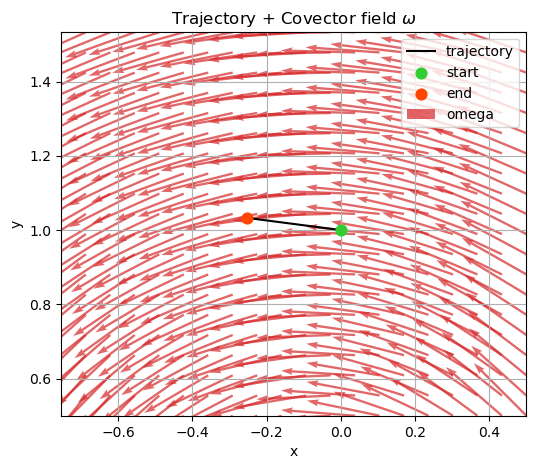

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# ---- Trajectory ----
positions = traj[0].detach().numpy()   

ax.plot(
    positions[:, 0],
    positions[:, 1],
    color='black',
    label="trajectory"
)

# ---- Start and End Points ----
# Start point: green, End point: red
ax.scatter(
    positions[0, 0], positions[0, 1], 
    color="limegreen", s=60, zorder=5, label="start"
)
ax.scatter(
    positions[-1, 0], positions[-1, 1],
    color="orangered", s=60, zorder=5, label="end"
)

# ---- Define plotting window from trajectory ----
xmin, xmax = positions[:, 0].min(), positions[:, 0].max()
ymin, ymax = positions[:, 1].min(), positions[:, 1].max()

# Add margin
margin = 0.5
xmin -= margin; xmax += margin
ymin -= margin; ymax += margin

# ---- Grid adapted to trajectory frame ----
x = np.linspace(xmin, xmax, 20)
y = np.linspace(ymin, ymax, 20)
xx, yy = np.meshgrid(x, y)
points = np.stack([xx.ravel(), yy.ravel()], axis=1)

# Avoid origin if needed
mask = np.linalg.norm(points, axis=1) > 0.1
masked_points = points[mask]

pts_tensor = torch.tensor(masked_points, dtype=torch.float32)
omega_vecs = omega_form(pts_tensor).detach().numpy()

# ---- Covector field ----
ax.quiver(
    masked_points[:, 0],
    masked_points[:, 1],
    omega_vecs[:, 0],
    omega_vecs[:, 1],
    angles="xy",
    scale_units="xy",
    scale=2.5,
    color="tab:red",
    width=0.005,
    alpha=0.7,
    label="omega"
)

# ---- Styling ----
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Trajectory + Covector field $\omega$")
ax.grid(True)
ax.legend()

plt.show()